# **EMBEDDING**

**LSB (least Significant Bit)** <br>
Dalam steganografi, LSB adalah metode penyamaran data yang paling umum dan sederhana. Tujuannya untuk menyembunyikan pesan 
rahasia (seperti file atau teks) ke dalam sebuah media pembawa (biasanya gambar digital) tanpa menimbulkan kecurigaan secara visual.<br><br>

Cara Kerja Modifikasi Bit:

- Setiap piksel pada gambar digital (misal RGB), terdiri dari komponen warna yang diwakili
oleh deretan angka biner 8-bit (1 byte). 
- Bit paling kiri disebut Most Significant Bit (MSB), mengubah bit ini akan merusak warna gambar secara drastis.
- Bit paling kanan disebut Least Significant Bit (LSB), mengubah bit ini hanya akan merubah nilai desimal sebesar 1 angka,
yang dampak visualnya hampir tidak bisa dideteksi oleh mata manusia.
- Teknik LSB ini, bekerja dengan cara membungkar pesan rahasia menjadi biner, lalu menyisipkannya satu per satu untuk menggantikan posisi LSB pada piksel-piksel gambar.<br><br>

Contoh:<br>
1. Misal, memiliki satu nilai biner dari piksel warna merah: 10101100 (desimal: 172)<br>
2. Lalu, memiliki potongan pesan rahasia berupa bit: 1<br>
3. LSB menimpa bit paling ujung kanan gambar (0) dengan bit pesan rahasia tersebut (1) sehingga piksel gambar berubah menjadi: 10101101 (desimal: 173)


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

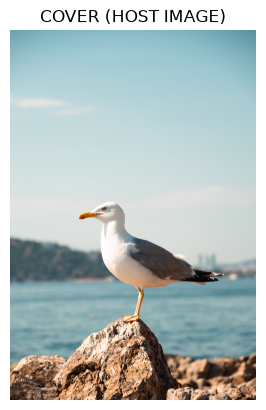

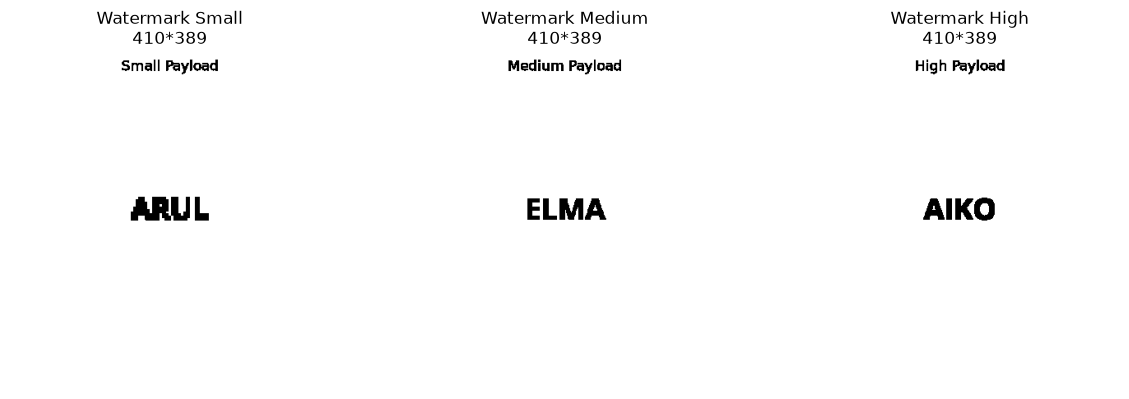

In [ ]:
# --- PERSIAPAN DATA ---
# baca gambar cover
cover = cv2.imread('../data/raw/cover-hostimage.jpg') # BGR, warna asli
if cover is None:
    raise FileNotFoundError("Gambar cover tidak ditemukan atau gagal dibaca.")

plt.imshow(cv2.cvtColor(cover, cv2.COLOR_BGR2RGB)) # konversi BGR ke RGB, karena matplotlib mengasumsikan urutan RGB, sedangkan openCV menyimpan BGR
plt.title("COVER (HOST IMAGE)")
plt.axis('off')
plt.show()

# baca logo/watermark, threshold watermark jadi biner 0/255, lalu ubah ke 0/1
def load_and_binarize(path, thresh=127):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FIleNotFoundError(f"Gambar '{path}' tidak ditemukan atau gagal dibaca")
    # ubah nilai piksel logo (watermark) menjadi biner agar bisa disisipkan
    img_bit = img_bw // 255
    return img_bit

logo1_small_bw = cv2.imread("../data/resize/resize_small_payload.png", cv2.IMREAD_GRAYSCALE)
logo2_medium_bw = cv2.imread("../data/resize/resize_medium_payload.png", cv2.IMREAD_GRAYSCALE)
logo3_high_bw = cv2.imread("../data/resize/resize_high_payload.png", cv2.IMREAD_GRAYSCALE)

# tampilkan preview ketiga watermark biner
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, wm, label in zip(
    axes,
    [watermark1_bit, watermark2_bit, watermark3_bit],
    ["Small", "Medium", "High"]
):
    h, w = wm.shape
    ax.imshow(wm, cmap='gray')
    ax.set_title(f"Watermark {label}\n{h}*{w}")
    ax.axis('off')

plt.tight_layout()
plt.show()


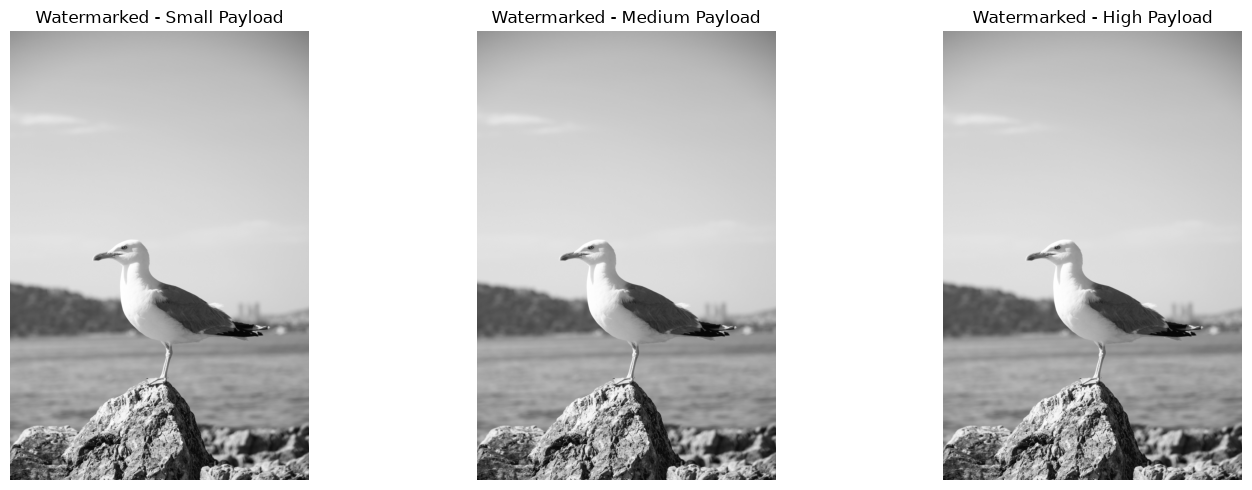

In [ ]:
# --- PROSES EMBEDDING ---
# LSB (least significanat bit)
# sisipkan watermark_bit ke LSB pojok kiri-atas over_img menggunakan teknik bitwise AND-OR. Mengembalikan gambar watermarked baru tanpa mengubah cover asli
# channel: 0 = blue, 1 = green, 2 = red (urutan OpenCV/BGR), default channel= 0
def embed_lsb_color_single_channel(cover_img, watermark_bit, channel=0):
    h, w = watermark_bit.shape
    
    assert cover_img.shape[0] >= h and cover_img.shape[1] >= w, \
    f"Cover ({cover.img}) lebih kecil dari watermark {h}*{w}"

    # salin gambar cover agar aslinya tidak rusak
    watermarked_image = cover_img.copy()

    # ambil area cover sebesar ukuran watermark di pojok kiri atas (baris 0:h, kolom 0:w)
    cover_region = watermarked_image[0:h, 0:w]

    # hapus LSB dari area cover tsb dgn operator bitwise AND (&) angka 254 (11111110)
    cover_cleared_lsb = cover_region & 254

    # sisipkan bit watermark ke LSB yang sudah kosong dengan operator Bitwise OR (|)
    watermarked_region = cover_cleared_lsb | watermark1_bit

    # masukkan kembali aarea yang sudah disisipi ke dalam gambar watermarkerd_imgae
    watermarked_image[0:h, 0:w] = watermarked_region

    return watermarked_image

# Embedding masing-masing watermark ke Cover Asli (bukan hasil sebelumnya)
watermarked_small = embed_lsb(cover, watermark1_bit)
watermarked_medium = embed_lsb(cover, watermark2_bit)
watermarked_high = embed_lsb(cover, watermark3_bit)

# Tampilkan hasil embedding
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, label in zip (
    axes,
    [watermarked_small, watermarked_medium, watermarked_high],
    ["Small Payload", "Medium Payload", "High Payload"]
):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Watermarked - {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [6]:
# proses extraction

In [7]:
# visualisasi hasil